# Environnement

In [66]:
import enum

class PROCESS_TYPE(enum.Enum):
    data_distribution = "data_distribution"
    normalize_img = "normalize_img"

class MODEL_TYPE(enum.Enum):
    logistic_regression = "logistic_regression"
    random_forest = "random_forest"
    svm = "svm"

TEST_SIZE = 0.2
VAL_SIZE = 0.2
IMG_SIZE = (256,256)
MAX_ITER = 2000
PROCESS: list[PROCESS_TYPE] = []
MODEL = MODEL_TYPE.logistic_regression


    

# Load Data

In [67]:
from pathlib import Path

test_normal_imgs = Path("test/NORMAL")
test_pneumonia_imgs = Path("test/PNEUMONIA")

train_normal_imgs = Path("train/NORMAL")
train_pneumonia_imgs = Path("train/PNEUMONIA")

val_normal_imgs = Path("val/NORMAL")
val_pneumonia_imgs = Path("val/PNEUMONIA")

# Data Visualisation
## Distribution


/Users/nicolasdambreville/Dev/Epitech/T-DEV-810/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


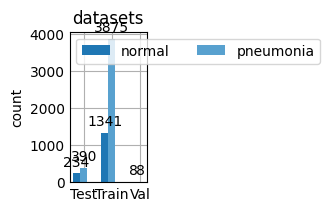

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List

datasets = ("Test", "Train", "Val")

test_normal_paths = [img for img in test_normal_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
test_pneumonia_paths = [img for img in test_pneumonia_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
train_normal_paths = [img for img in train_normal_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
train_pneumonia_paths = [img for img in train_pneumonia_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
val_normal_paths = [img for img in val_normal_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]
val_pneumonia_paths = [img for img in val_pneumonia_imgs.iterdir() if img.suffix in ['.jpeg', '.jpg', '.png']]

def display_distribution(list_test_normal_imgs : List[Path], list_test_pneumonia_imgs : List[Path], list_train_normal_imgs : List[Path], list_train_pneumonia_imgs : List[Path], list_val_normal_imgs : List[Path], list_val_pneumonia_imgs : List[Path]):
    groups = {
        'normal': (len(list_test_normal_imgs), len(list_train_normal_imgs), len(list_val_normal_imgs)),
        'pneumonia': (len(list_test_pneumonia_imgs), len(list_train_pneumonia_imgs), len(list_val_pneumonia_imgs)),
    }


    x = np.arange(len(datasets))  
    width = 0.25 
    multiplier = 0

    _, ax = plt.subplots(layout='constrained')

    for attribute, measurement in groups.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3)
        multiplier += 1

    ax.set_ylabel('count')
    ax.set_title('datasets')
    ax.set_xticks(x + width, datasets)
    ax.legend(loc='upper left', ncols=3)

    plt.show()

display_distribution(test_normal_paths, test_pneumonia_paths, train_normal_paths, train_pneumonia_paths, val_normal_paths, val_pneumonia_paths)

# Dataset
## fix distribution

/Users/nicolasdambreville/Dev/Epitech/T-DEV-810/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


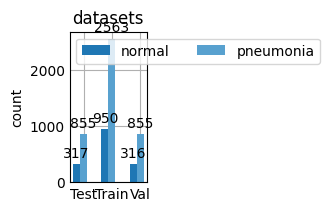

In [69]:
from sklearn.model_selection import train_test_split

def data_distribution(train_normal_paths : List[Path], train_pneumonia_paths : List[Path], val_normal_paths : List[Path], val_pneumonia_paths : List[Path], test_normal_paths : List[Path], test_pneumonia_paths : List[Path]) -> tuple[List[Path], List[Path], List[Path], List[int], List[int], List[int]]:
    PROCESS.append(PROCESS_TYPE.data_distribution)
    all_paths = train_normal_paths + train_pneumonia_paths + val_normal_paths + val_pneumonia_paths + test_normal_paths + test_pneumonia_paths
    all_labels = [0] * len(train_normal_paths) + [1] * len(train_pneumonia_paths) + [0] * len(val_normal_paths) + [1] * len(val_pneumonia_paths) + [0] * len(test_normal_paths) + [1] * len(test_pneumonia_paths)

    train_paths, val_paths, y_train, y_val = train_test_split(
        all_paths,
        all_labels,
        test_size=TEST_SIZE+VAL_SIZE,
        random_state=42,
        stratify=all_labels
    )

    val_paths, test_paths, y_val, y_test = train_test_split(
        val_paths,
        y_val,
        test_size=VAL_SIZE/(TEST_SIZE+VAL_SIZE),
        random_state=42,
        stratify=y_val
    )

    return train_paths, val_paths, test_paths, y_train, y_val, y_test

train_paths, val_paths, test_paths, y_train, y_val, y_test = data_distribution(train_normal_paths, train_pneumonia_paths, val_normal_paths, val_pneumonia_paths, test_normal_paths, test_pneumonia_paths)


display_distribution([test_path for test_path in test_paths if test_path.parent.name == "NORMAL"], [test_path for test_path in test_paths if test_path.parent.name == "PNEUMONIA"], [train_path for train_path in train_paths if train_path.parent.name == "NORMAL"], [train_path for train_path in train_paths if train_path.parent.name == "PNEUMONIA"], [val_path for val_path in val_paths if val_path.parent.name == "NORMAL"], [val_path for val_path in val_paths if val_path.parent.name == "PNEUMONIA"])


## Normalize image pixel 

Text(0.5, 1.0, 'Scatter Plot of Image Dimensions')

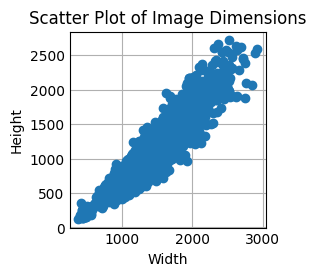

In [70]:
from PIL import Image
from typing import List

img_width:List[int]=[]
img_height:List[int]=[]
for img_lists in [ train_paths, val_paths, test_paths]:
    for img_path in img_lists: 
        assert  isinstance(img_path,Path)   
        img = Image.open(img_path)
        width, height = img.size
        img_width.append(width)
        img_height.append(height)

plt.scatter(img_width, img_height)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Scatter Plot of Image Dimensions')

In [71]:
def normalize_img(train_paths : List[Path],val_paths : List[Path], test_paths : List[Path]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Normalize images by resizing them to a common size and flattening them into 1D arrays."""
    PROCESS.append(PROCESS_TYPE.normalize_img)

    images_train: List[np.ndarray] = []
    images_val: List[np.ndarray] = []
    images_test: List[np.ndarray] = []
    
    for list_imgs, images in zip([train_paths, val_paths, test_paths], [images_train, images_val, images_test]):
        for img_path in list_imgs: 
            assert  isinstance(img_path,Path)   
            img = Image.open(img_path).convert("L")
            img = img.resize(IMG_SIZE)
            img_array = np.array(img)
            img_flat = img_array.flatten()
            images.append(img_flat)

    return np.array(images_train), np.array(images_val), np.array(images_test)

X_train,X_val,X_test =normalize_img(train_paths,val_paths,test_paths)

# Compute 

## Logistic Regression

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(max_iter=MAX_ITER) if MODEL == MODEL_TYPE.logistic_regression else None
if model is None:
    raise ValueError("Model not implemented")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# Result Visualization
## ROC 


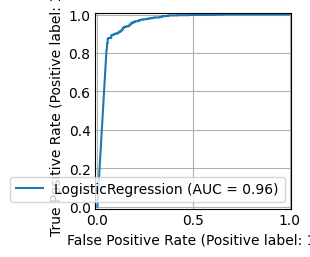

In [73]:
from sklearn.metrics import RocCurveDisplay

# ROC curve help to visualize the performance of the model with different thresholds
svc_disp = RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

# Matrice de confusion 

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\n")

cm = confusion_matrix(y_test, y_pred)

df_cm = pd.DataFrame(
    cm,
    index=["Actual NORMAL", "Actual PNEUMONIA"],
    columns=["Pred NORMAL", "Pred PNEUMONIA"]
)

print(df_cm)
print("\n")

# calculate AUC using cross-validation on the training set to get a more robust estimate of the model's performance.
# if the mean AUC is high and the standard deviation is low, it suggests that the model is performing well and is likely to generalize to unseen data.
# if the mean AUC is low or the standard deviation is high, it may indicate that the model is not performing well and may require further tuning or a different approach.
# Note that AUC is a useful metric for evaluating the performance of a binary classification model, especially when the classes are imbalanced, as it considers both the true positive rate and the false positive rate across different thresholds.
scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")
print(f"CV AUC: {scores.mean():.3f} ± {scores.std():.3f}" + "\n")

# recall, because it is more important to correctly identify pneumonia cases than to correctly identify normal cases in this context.
print("Recall")


fn = cm[1, 0]
tp = cm[1, 1]

recall = tp / (fn + tp)
print(recall)
print("\n")


# compare AUC on train and test sets to check for overfitting, and underfitting. 
#   - If the AUC on the train set is much higher than the AUC on the test set, it may indicate that the model is overfitting. 
#   - If the AUC on both sets is low, it may indicate that the model is underfitting.
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Train AUC:", train_auc)
print("Test AUC:", test_auc)


Accuracy: 0.9146757679180887


                  Pred NORMAL  Pred PNEUMONIA
Actual NORMAL             264              53
Actual PNEUMONIA           47             808


CV AUC: 0.974 ± 0.001

Recall
0.9450292397660819


Train AUC: 1.0
Test AUC: 0.955142324792001


# Register result 

In [ ]:
import json
from datetime import datetime

envs_dict = {
    "TEST_SIZE": TEST_SIZE,
    "VAL_SIZE": VAL_SIZE,
    "IMG_SIZE": IMG_SIZE,
    "MAX_ITER": MAX_ITER,
    "PROCESS": [process.value for process in PROCESS],
}

result_dict = {
    "accuracy": accuracy,
    "confusion_matrix": {
        "TP": int(tp),
        "FP": int(cm[0, 1]),
        "TN": int(cm[0, 0]),
        "FN": int(fn)
    },
    "cv_auc": (scores.mean(), scores.std()),
    "recall": recall,
    "train_auc": train_auc,
    "test_auc": test_auc
}

with open("version.json", "r+") as f:
    file = f.read()
    if file.strip():
        version_data = json.loads(file)
    else:
        version_data = {"versions":[]}
    version_data["versions"].append({datetime.now().isoformat() : {
        "envs": envs_dict,
        "results": result_dict,
        "model" : MODEL.value
    }})
    json.dump(version_data, f, indent=4)

## Compare

In [100]:
from typing import Any, Dict

results: Dict[str, Any]  = {}

with open("version.json", "r") as f:
    version_data = json.load(f)["versions"]
    for version in version_data:
        for key, value in version.items():
            print(f"Version: {key}")
            key_date = datetime.fromisoformat(key)
            results[key_date.date()] = {
                "accuracy": f"{value['results']['accuracy']:.3f}",
                "cv_auc": f"{value['results']['cv_auc'][0]:.3f} ± {value['results']['cv_auc'][1]:.3f}",
                "recall": f"{value['results']['recall']:.3f}",
                "train_auc": f"{value['results']['train_auc']:.3f}",
                "test_auc": f"{value['results']['test_auc']:.3f}"
            }

df = pd.DataFrame.from_dict(results, orient="index")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
print(df)

Version: 2026-03-02T17:21:16.596950
           accuracy         cv_auc recall train_auc test_auc
2026-03-02    0.915  0.974 ± 0.001  0.945     1.000    0.955


- [] ajouter un tableau avec le résultat et les étape de prépapration de dataset + entrainemnt
- [] point à ajuster normaliser le bit de nuance de gris entre 0 et 1 
- [] augmenter ou diminuer la résolution d'image 
- [] augmenter la taille du dataset d'entrainement 
- [] a quoi sert le val dataset 
- [] tester d'autre modèle 
- [] tester avec une meilleur répartition malade _ non malade 